# Task 7: Machine Translation (English ↔ Dutch)

## Objective
Build one bidirectional model for round-translation of speech transcripts.

## Dataset
- Corpus Name: OpenSubtitles
- Package: Moses
- Website: http://opus.nlpl.eu/legacy/OpenSubtitles-v2024.php
- Release: v2024
- Release date: Fri Feb 14 10:40:45 EET 2025

In [1]:
import numpy as np
import tensorflow as tf
from keras import layers
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import re
import random

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

## Step 1: Dataset Selection & Loading

- Select and download an EN-NL dataset
- Load the data
- Basic exploration and quality checks
- Sample to manageable size (100k-200k pairs)

In [11]:
# Load the OpenSubtitles data
with open('../Data/Translation/OpenSubtitles.en-nl.en', 'r', encoding='utf-8') as f:
    en_sentences = [line.strip() for line in f.readlines()]

with open('../Data/Translation/OpenSubtitles.en-nl.nl', 'r', encoding='utf-8') as f:
    nl_sentences = [line.strip() for line in f.readlines()]

In [12]:
# Sample to manageable size
SAMPLE_SIZE = 100000 

# Sample randomly to get diverse data
indices = random.sample(range(len(en_sentences)), SAMPLE_SIZE)
en_sentences = [en_sentences[i] for i in sorted(indices)]
nl_sentences = [nl_sentences[i] for i in sorted(indices)]

print(f"Sampled {len(en_sentences)} sentence pairs")

Sampled 100000 sentence pairs


In [13]:
# Check alignment
assert len(en_sentences) == len(nl_sentences), 'Misaligned files!'

# Check for empty sentences
en_empty = sum(1 for s in en_sentences if not s.strip())
nl_empty = sum(1 for s in nl_sentences if not s.strip())
print(f'Empty EN sentences: {en_empty}')
print(f'Empty NL sentences: {nl_empty}')

Empty EN sentences: 0
Empty NL sentences: 0


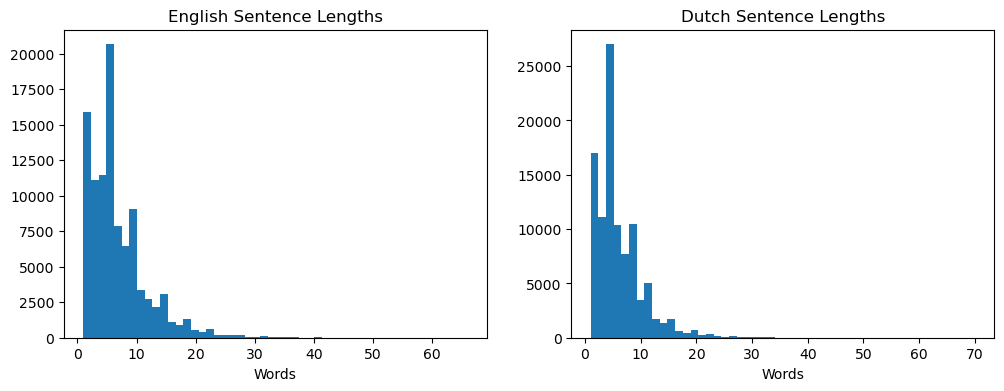

In [14]:
# Length distribution
en_lengths = [len(s.split()) for s in en_sentences]
nl_lengths = [len(s.split()) for s in nl_sentences]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(en_lengths, bins=50)
ax1.set_title('English Sentence Lengths')
ax1.set_xlabel('Words')
ax2.hist(nl_lengths, bins=50)
ax2.set_title('Dutch Sentence Lengths')
ax2.set_xlabel('Words')
plt.show()

In [15]:
# Basic preprocessing
def preprocess_sentence(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r'([?.!,¿])', r' \1 ', sentence)
    sentence = re.sub(r'[" "]+', ' ', sentence)
    sentence = sentence.strip()
    return '<start> ' + sentence + ' <end>'

en_processed = [preprocess_sentence(s) for s in en_sentences]
nl_processed = [preprocess_sentence(s) for s in nl_sentences]

In [20]:
# Create bidirectional samples with direction tokens
en_to_nl = ['<2nl> ' + en for en in en_processed]
nl_to_en = ['<2en> ' + nl for nl in nl_processed]

# Combine into bidirectional dataset
all_sources = en_to_nl + nl_to_en
all_targets = nl_processed + en_processed

print(f'Total training samples: {len(all_sources)}')

print("\nExample EN→NL sample:")
print(f"Source: {all_sources[0]}")
print(f"Target: {all_targets[0]}")

print("\nExample NL→EN sample:")
print(f"Source: {all_sources[len(en_processed)]}")
print(f"Target: {all_targets[len(en_processed)]}")

Total training samples: 200000

Example EN→NL sample:
Source: <2nl> <start> do you know where the prisoner was transported to ? <end>
Target: <start> weet je waar de gevangene naartoe is gebracht ? <end>

Example NL→EN sample:
Source: <2en> <start> weet je waar de gevangene naartoe is gebracht ? <end>
Target: <start> do you know where the prisoner was transported to ? <end>


## Step 2: Tokenization & Vocabulary

- Use Keras `TextVectorization`
- Create tokenizers for both EN and NL
- Build vocabularies
- Add special tokens: `<pad>`, `<sos>`, `<eos>`, `<unk>`, `<2nl>`, `<2en>`
- Vectorize the data

In [21]:
# Hyperparameters
VOCAB_SIZE = 10000
MAX_SEQ_LENGTH = 40

# Combined text corpus for vocabulary
combined_corpus = all_sources + all_targets

print(f'Building vocabulary from {len(combined_corpus)} sentences')

Building vocabulary from 400000 sentences


In [22]:
# Create single TextVectorization layer for both languages
vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_SEQ_LENGTH,
    standardize=None
)

# Adapt to the combined corpus
vectorizer.adapt(combined_corpus)

# Get vocabulary
vocabulary = vectorizer.get_vocabulary()
print(f'Vocabulary size: {len(vocabulary)} tokens')
print(f'First 20 tokens: {vocabulary[:20]}')

# Check if the special tokens are there
special_tokens = ['<2nl>', '<2en>', '<start>', '<end>']
for token in special_tokens:
    if token in vocabulary:
        print(f'"{token}" found at index {vocabulary.index(token)}')
    else:
        print(f'"{token}" NOT FOUND')

Vocabulary size: 10000 tokens
First 20 tokens: ['', '[UNK]', np.str_('<start>'), np.str_('<end>'), np.str_('.'), np.str_(','), np.str_('<2nl>'), np.str_('<2en>'), np.str_('?'), np.str_('you'), np.str_('ik'), np.str_('the'), np.str_('-'), np.str_('je'), np.str_('is'), np.str_('i'), np.str_('to'), np.str_('het'), np.str_('de'), np.str_('a')]
"<2nl>" found at index 6
"<2en>" found at index 7
"<start>" found at index 2
"<end>" found at index 3


In [23]:
# Split the data
train_src, val_src, train_tgt, val_tgt = train_test_split(
    all_sources, all_targets, test_size=0.2, random_state=42
)

print(f'Training samples: {len(train_src)}')
print(f'Validation sampels: {len(val_src)}')

Training samples: 160000
Validation sampels: 40000


In [24]:
# Vectorize all data
train_src_vec = vectorizer(train_src)
train_tgt_vec = vectorizer(train_tgt)
val_src_vec = vectorizer(val_src)
val_tgt_vec = vectorizer(val_tgt)

print('Vectorized shapes:')
print(f'Train source: {train_src_vec.shape}')
print(f'Train target: {train_tgt_vec.shape}')

Vectorized shapes:
Train source: (160000, 40)
Train target: (160000, 40)


In [25]:
BATCH_SIZE = 64

# Create datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_src_vec, train_tgt_vec))
train_dataset = train_dataset.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((val_src_vec, val_tgt_vec))
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f'Training batches: {len(train_dataset)}')
print(f'Validation batches: {len(val_dataset)}')

Training batches: 2500
Validation batches: 625


## Step 3: Data Preparation

- Create bidirectional samples (EN→NL and NL→EN with direction tokens)
- Train/validation/test split
- Create TensorFlow or PyTorch datasets with batching
- Implement padding and collation

## Step 4: Model Architecture

- Positional Encoding (sinusoidal)
- Multi-Head Attention (scaled dot-product)
- Encoder Layers (self-attention + feed-forward)
- Decoder Layers (masked self-attention + cross-attention + feed-forward)
- Complete Transformer (encoder + decoder + output projection)

## Step 5: Training

- Custom learning rate schedule (warmup + decay)
- Loss function with padding mask
- Training loop with teacher forcing
- Validation monitoring
- Checkpoint saving

## Step 6: Inference

- Greedy decoding or beam search
- Translation functions for both directions
- Test on sample sentences

## Step 7: Apply to Transcript

- Load the final transcript from Task 3
- Round-translate each sentence (EN→NL→EN)
- Save to CSV with columns: 'Original', 'Translation', 'English Translation'

## Step 8: Manual Evaluation

- 150 lines
- Score: 3 (correct), 2 (minor error), 1 (incorrect)
- Comment on errors for scores 1-2

## Step 9: Linguistic Analysis

- Categorize error types
- Provide linguistic explanations
- Write `findings_round_translation.pdf`